# Gym Duckietown 🦆

Gym-Duckietown is a simulator for the Duckietown Universe, written in pure Python/OpenGL (Pyglet). It places your agent, a Duckiebot, inside of an instance of a Duckietown: a loop of roads with turns, intersections, obstacles, Duckie pedestrians, and other Duckiebots. It can be a pretty hectic place!

Have a look at the GitHub repo for more details: https://github.com/duckietown/gym-duckietown

There are several maps and tracks available which can be accessed through registered gym environments, each corresponding to a different map file:

- Duckietown-straight_road-v0
- Duckietown-4way-v0
- Duckietown-udem1-v0
- Duckietown-small_loop-v0
- Duckietown-small_loop_cw-v0
- Duckietown-zigzag_dists-v0
- Duckietown-loop_empty-v0
- Duckietown-loop_obstacles-v0 (static obstacles in the road)
- Duckietown-loop_pedestrians-v0 (moving obstacles in the road)

We will work with the following for our challenges:

- Getting Started: Duckietown-small_loop-v0
- Basic: Duckietown-small_loop-v0
- Medium: Duckietown-loop_empty-v0
- Advanced: Duckietown-loop_obstacles-v0 (static obstacles in the road)

- Bonus: Duckietown-zigzag_dists-v0, Duckietown-loop_pedestrians-v0 (moving obstacles in the road)

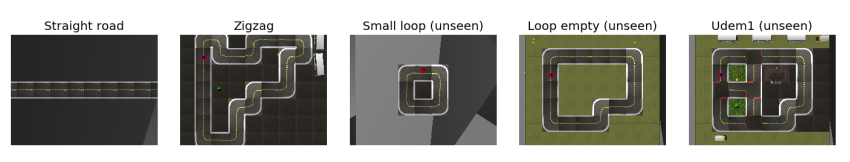


Below is the standard control loop with the small loop environment loaded:

In [9]:
import gym
import gym_duckietown
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import os
from datetime import datetime

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class FrameStack:
    """Stack the last k frames for temporal information"""
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)
    
    def reset(self, observation):
        """Initialize with first observation"""
        # Convert to 64x64 if needed
        if observation.shape[0] != 64:
            obs_pil = Image.fromarray(observation)
            obs_pil = obs_pil.resize((64, 64), Image.LANCZOS)
            observation = np.array(obs_pil)
        
        # Normalize to [0, 1]
        observation = observation.astype(np.float32) / 255.0
        
        # Stack k copies of first frame
        for _ in range(self.k):
            self.frames.append(observation)
        
        return self.get_state()
    
    def push(self, observation):
        """Add new frame and return stacked state"""
        # Convert to 64x64 if needed
        if observation.shape[0] != 64:
            obs_pil = Image.fromarray(observation)
            obs_pil = obs_pil.resize((64, 64), Image.LANCZOS)
            observation = np.array(obs_pil)
        
        # Normalize
        observation = observation.astype(np.float32) / 255.0
        self.frames.append(observation)
        
        return self.get_state()
    
    def get_state(self):
        """Get current state as stacked frames"""
        # Stack frames along channel dimension
        # Shape: (4*3, 64, 64) = (12, 64, 64)
        stacked = np.concatenate(list(self.frames), axis=2)
        # Transpose to (C, H, W) for PyTorch
        stacked = np.transpose(stacked, (2, 0, 1))
        return stacked

class DQN(nn.Module):
    """Deep Q-Network for continuous action space"""
    def __init__(self, input_channels=12, n_actions=2):
        super(DQN, self).__init__()
        
        # CNN layers for image processing
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
        # Calculate size after convolutions
        def conv2d_size_out(size, kernel_size, stride):
            return (size - (kernel_size - 1) - 1) // stride + 1
        
        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(64, 8, 4), 4, 2), 3, 1)
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(64, 8, 4), 4, 2), 3, 1)
        linear_input_size = convw * convh * 64
        
        # Fully connected layers
        self.fc1 = nn.Linear(linear_input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        
        # Separate heads for each action dimension
        self.action1_head = nn.Linear(256, 11)  # Discretize [-0.5, 0.5] into 11 bins
        self.action2_head = nn.Linear(256, 11)  # Discretize [-0.2, 0.2] into 11 bins
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # Output Q-values for discretized actions
        action1_q = self.action1_head(x)
        action2_q = self.action2_head(x)
        
        return action1_q, action2_q

class ReplayMemory:
    """Experience replay buffer"""
    def __init__(self, capacity=50000):
        self.memory = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        
        return (torch.FloatTensor(state).to(device),
                torch.LongTensor(action).to(device),
                torch.FloatTensor(reward).to(device),
                torch.FloatTensor(next_state).to(device),
                torch.FloatTensor(done).to(device))
    
    def __len__(self):
        return len(self.memory)

class DuckyRL:
    """Main RL training class"""
    def __init__(self, env_name='Duckietown-small_loop-v0', lr=1e-4):
        self.env = gym.make(env_name)
        self.frame_stack = FrameStack(k=4)
        
        # Networks
        self.q_network = DQN(input_channels=12).to(device)
        self.target_network = DQN(input_channels=12).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Training components
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayMemory(capacity=50000)
        
        # Action space discretization
        self.action1_space = np.linspace(0.1, 1, 11)  # Forward/backward
        self.action2_space = np.linspace(-1, 1, 11)  # Left/right turn
        
        # Training parameters
        self.batch_size = 32
        self.gamma = 0.99
        self.eps_start = 1.0
        self.eps_end = 0.01
        self.eps_decay = 0.995
        self.epsilon = self.eps_start
        
        # Logging
        self.episode_rewards = []
        self.episode_lengths = []
        self.training_losses = []
    
    def discretize_action(self, continuous_action):
        """Convert continuous action to discrete indices"""
        idx1 = np.argmin(np.abs(self.action1_space - continuous_action[0]))
        idx2 = np.argmin(np.abs(self.action2_space - continuous_action[1]))
        return [idx1, idx2]
    
    def get_continuous_action(self, discrete_indices):
        """Convert discrete indices back to continuous actions"""
        return [self.action1_space[discrete_indices[0]], 
                self.action2_space[discrete_indices[1]]]
    
    def select_action(self, state):
        """Epsilon-greedy action selection"""
        if random.random() < self.epsilon:
            # Random action
            return [random.randint(0, 10), random.randint(0, 10)]
        else:
            # Greedy action from Q-network
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q1, q2 = self.q_network(state_tensor)
                action1 = q1.max(1)[1].item()
                action2 = q2.max(1)[1].item()
                return [action1, action2]

    def calculate_reward(self, base_reward, action, done):
        """
        Custom reward function that encourages faster driving
        
        Args:
            base_reward: Original reward from environment
            action: [velocity, steering] continuous action
            done: Whether episode ended
        
        Returns:
            modified_reward: Enhanced reward with speed bonus
        """
        velocity = action[0]  # Forward speed
        steering = abs(action[1])  # Absolute steering angle
        
        # Start with base reward
        reward = base_reward
        
        # Speed bonus: reward faster forward movement
        speed_bonus = velocity * 0.2  # Adjust multiplier as needed
        reward += speed_bonus
        
        # Penalty for sharp turns (encourages smooth driving)
        #steering_penalty = steering * 0.2
        #reward -= steering_penalty
        
        # Large penalty for crashing/going off track
        if done and base_reward < 0:
            reward -= 100  # Crash penalty
        
        return reward
    
    def optimize_model(self):
        """Train the Q-network"""
        if len(self.memory) < self.batch_size:
            return
        
        # Sample batch
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        # Current Q values
        current_q1, current_q2 = self.q_network(states)
        current_q1 = current_q1.gather(1, actions[:, 0].unsqueeze(1))
        current_q2 = current_q2.gather(1, actions[:, 1].unsqueeze(1))
        
        # Next Q values from target network
        with torch.no_grad():
            next_q1, next_q2 = self.target_network(next_states)
            next_q1_max = next_q1.max(1)[0]
            next_q2_max = next_q2.max(1)[0]
            next_q_value = (next_q1_max + next_q2_max) / 2  # Average Q-value
            
            target_q_value = rewards + (self.gamma * next_q_value * (1 - dones))
        
        # Loss
        loss1 = F.mse_loss(current_q1.squeeze(), target_q_value)
        loss2 = F.mse_loss(current_q2.squeeze(), target_q_value)
        loss = loss1 + loss2
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.training_losses.append(loss.item())
    
    def train(self, num_episodes=5000, save_interval=100):
        print(f"Starting training for {num_episodes} episodes...")
    
        for episode in range(num_episodes):
            obs = self.env.reset()
            state = self.frame_stack.reset(obs)
        
            episode_reward = 0
            episode_length = 0
            max_steps = 400  # Prevent infinite episodes
        
            while episode_length < max_steps:
                # Select action
                discrete_action = self.select_action(state)
                continuous_action = self.get_continuous_action(discrete_action)
                
                # Take action
                next_obs, base_reward, done, info = self.env.step(continuous_action)
                next_state = self.frame_stack.push(next_obs)

                # Custom reword
                reward = self.calculate_reward(base_reward, continuous_action, done)
                
                # Store experience
                self.memory.push(state, discrete_action, reward, next_state, done)
                
                # Optimize
                if len(self.memory) >= self.batch_size:
                    self.optimize_model()
                
                # Update state
                state = next_state
                episode_reward += reward
                episode_length += 1
                
                # Debug print every 100 steps
                if episode_length % 100 == 0:
                    print(f"Episode {episode}, Step {episode_length}: Still running...")
                
                if done:
                    break
        
            # Log completion
            print(f"Episode {episode} finished: Steps={episode_length}, Reward={episode_reward:.3f}")
            
            # Decay epsilon
            self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)
            
            # Log episode
            self.episode_rewards.append(episode_reward)
            self.episode_lengths.append(episode_length)
            
            # Update target network every 10 episodes
            if episode % 10 == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())
            
            # Print progress
            if episode % save_interval == 0:
                avg_reward = np.mean(self.episode_rewards[-save_interval:]) if len(self.episode_rewards) >= save_interval else episode_reward
                print(f"Episode {episode}: Avg Reward = {avg_reward:.3f}, Epsilon = {self.epsilon:.3f}")
                
                # Save model
                self.save_model(f"orginal_{episode}.pth")

        print("\n" + "="*50)
        print("Training complete!")
        
        # Save the final model
        final_episode = num_episodes - 1
        self.save_model(f"orginal_{final_episode}.pth")
        self.save_model("ducky_dqn_final.pth")  # Also save as "final" for easy access
        
        # Print final statistics
        if len(self.episode_rewards) >= 10:
            final_avg = np.mean(self.episode_rewards[-10:])
            print(f"Final Average Reward (last 10 episodes): {final_avg:.3f}")
        
        print("="*50 + "\n")
        
        self.env.close()
        
    
    def save_model(self, filename):
        """Save model weights"""
        torch.save({
            'q_network': self.q_network.state_dict(),
            'target_network': self.target_network.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'episode_rewards': self.episode_rewards
        }, filename)
        print(f"Model saved to {filename}")
    
    def load_model(self, filename):
        """Load model weights"""
        checkpoint = torch.load(filename, map_location=device)
        self.q_network.load_state_dict(checkpoint['q_network'])
        self.target_network.load_state_dict(checkpoint['target_network'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.epsilon = checkpoint['epsilon']
        self.episode_rewards = checkpoint['episode_rewards']
        print(f"Model loaded from {filename}")
    
    def test(self, num_episodes=5):
        """Test the trained model"""
        print(f"Testing for {num_episodes} episodes...")
        
        test_rewards = []
        
        for episode in range(num_episodes):
            obs = self.env.reset()
            state = self.frame_stack.reset(obs)
            
            episode_reward = 0
            
            while True:
                # Always use greedy action during testing
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                    q1, q2 = self.q_network(state_tensor)
                    action1 = q1.max(1)[1].item()
                    action2 = q2.max(1)[1].item()
                    discrete_action = [action1, action2]
                
                continuous_action = self.get_continuous_action(discrete_action)
                
                # Take action
                next_obs, reward, done, info = self.env.step(continuous_action)
                state = self.frame_stack.push(next_obs)
                
                episode_reward += reward
                
                # Optionally render
                frame = self.env.render(mode='rgb_array')
                
                if done:
                    break
            
            test_rewards.append(episode_reward)
            print(f"Test Episode {episode}: Reward = {episode_reward:.3f}")
        
        print(f"Average Test Reward: {np.mean(test_rewards):.3f}")
        self.env.close()

# === Training Script ===
if __name__ == "__main__":
    # Initialize RL agent
    agent = DuckyRL(env_name='Duckietown-small_loop-v0', lr=1e-4)
    
    # Train the agent
    agent.train(num_episodes=5000, save_interval=100)
    
    # Plot training results
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(agent.episode_rewards)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    
    plt.subplot(1, 3, 2)
    plt.plot(agent.episode_lengths)
    plt.title('Episode Lengths')
    plt.xlabel('Episode')
    plt.ylabel('Steps')
    
    if agent.training_losses:
        plt.subplot(1, 3, 3)
        plt.plot(agent.training_losses)
        plt.title('Training Loss')
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
    
    plt.tight_layout()
    plt.show()
    
    # Test the trained model
    agent.test(num_episodes=5)

INFO:gym-duckietown:Information about the graphics card:
 pyglet_version: 1.5.18
    information: dict[4]
                 │ vendor: Mesa/X.org
                 │ renderer: llvmpipe (LLVM 15.0.6, 256 bits)
                 │ version: 4.5 (Compatibility Profile) Mesa 22.3.6
                 │ shading-language-version: 4.50
  nvidia_around: True
DEBUG:gym-duckietown:loading map file "/usr/local/lib/python3.8/site-packages/duckietown_world/data/gd1/maps/small_loop.yaml"
INFO:gym-duckietown:done
INFO:gym-duckietown:Starting at [0.34389098 0.         0.72903543] 3.983898857018219
INFO:gym-duckietown:using DuckietownEnv


Using device: cpu
Starting training for 1000 episodes...


DEBUG:gym-duckietown:No tile found at [0.80179104 0.         1.79979525] (1, 3)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.3
DEBUG:gym-duckietown:pos: [0.75615492 0.         1.6920625 ]
DEBUG:gym-duckietown:l_pos: [0.84593221 0.         1.6540324 ]
DEBUG:gym-duckietown:r_pos: [0.66637763 0.         1.7300926 ]
DEBUG:gym-duckietown:f_pos: [0.80179104 0.         1.79979525]
DEBUG:gym-duckietown:[0.99245137 0.         1.13080624] corresponds to tile at (1, 1) which is not drivable: {'coords': (1, 1), 'kind': 'asphalt', 'angle': 1, 'drivable': False, 'texture': <gym_duckietown.graphics.Texture object at 0x7ff534158bb0>, 'color': array([1.17120244, 1.02385201, 0.8685663 , 1.        ])}
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.3
DEBUG:gym-duckietown:pos: [1.07273132 0.         1.18613598]
DEBUG:gym-duckietown:l_pos: [1.15301126 0.         1.2

Episode 0 finished: Steps=22, Reward=-1092.616
Episode 0: Avg Reward = -1092.616, Epsilon = 0.995
Model saved to ducky_dqn_episode_0.pth


DEBUG:gym-duckietown:[1.16904916 0.         1.02530265] corresponds to tile at (1, 1) which is not drivable: {'coords': (1, 1), 'kind': 'asphalt', 'angle': 1, 'drivable': False, 'texture': <gym_duckietown.graphics.Texture object at 0x7ff534158a60>, 'color': array([0.97236272, 1.03625005, 0.91900196, 1.        ])}
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [1.24833476 0.         0.98271398]
DEBUG:gym-duckietown:l_pos: [1.28382531 0.         1.04878531]
DEBUG:gym-duckietown:r_pos: [1.2128442  0.         0.91664265]
DEBUG:gym-duckietown:f_pos: [1.16904916 0.         1.02530265]
INFO:gym-duckietown:Starting at [0.60668997 0.         0.23789333] 0.9602526689688075


...

DEBUG:gym-duckietown:No tile found at [-0.00440926  0.          1.61977134] (-1, 2)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [0.0835482  0.         1.60070603]
DEBUG:gym-duckietown:l_pos: [0.09943596 0.         1.67400391]
DEBUG:gym-duckietown:r_pos: [0.06766044 0.         1.52740815]
DEBUG:gym-duckietown:f_pos: [-0.00440926  0.          1.61977134]
DEBUG:gym-duckietown:No tile found at [0.93961501 0.         1.80018086] (1, 3)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.3
DEBUG:gym-duckietown:pos: [0.92753308 0.         1.70343234]
DEBUG:gym-duckietown:l_pos: [0.91545114 0.         1.60668382]
DEBUG:gym-duckietown:r_pos: [0.93961501 0.         1.80018086]
DEBUG:gym-duckietown:f_pos: [1.0436313  0.         1.68893402]
INFO:gym-duckietown:Starting at [0.99078007 0.         1.60062714] 2.4182700706759217


Episode 102 finished: Steps=17, Reward=-1154.049


DEBUG:gym-duckietown:[0.61843458 0.         1.16715212] corresponds to tile at (1, 1) which is not drivable: {'coords': (1, 1), 'kind': 'asphalt', 'angle': 1, 'drivable': False, 'texture': <gym_duckietown.graphics.Texture object at 0x7ff5045f9d90>, 'color': array([1.10367198, 0.83168785, 0.95660871, 1.        ])}
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [0.56429144 0.         1.21905126]
DEBUG:gym-duckietown:l_pos: [0.51014831 0.         1.2709504 ]
DEBUG:gym-duckietown:r_pos: [0.61843458 0.         1.16715212]
DEBUG:gym-duckietown:f_pos: [0.50201248 0.         1.15407949]
INFO:gym-duckietown:Starting at [1.19118032 0.         0.37290057] 5.622333746062271


Episode 103 finished: Steps=68, Reward=-1113.672


KeyboardInterrupt: 

In [2]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 10.8 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 9.7 MB/s eta 0:00:00:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 11.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 10.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 10.9 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 2.0 MB/s eta 0:00:0000:0100:03m
   ━━━━━━━━━━━━━━

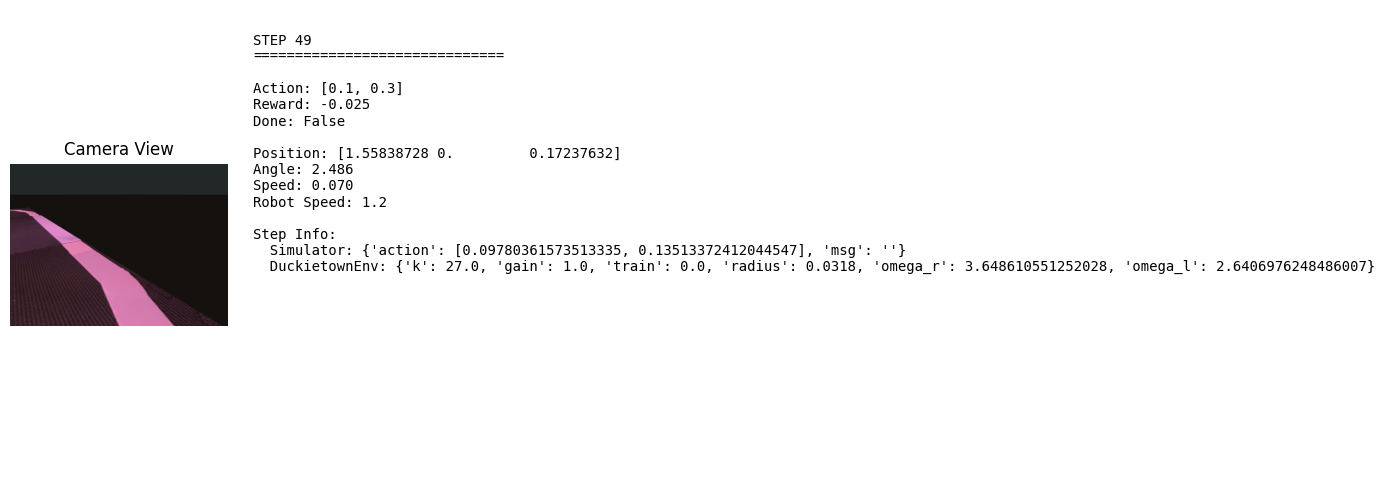

In [10]:
import gym
import gym_duckietown
from IPython.display import display, clear_output
from PIL import Image
import matplotlib.pyplot as plt

# Create the environment
env = gym.make('Duckietown-small_loop-v0')
env.reset()

# Run and show all info
done = False
step = 0

while not done and step < 50:
    # Take action
    action = [0.1, 0.3]
    observation, reward, done, info = env.step(action)
    
    # Clear screen
    clear_output(wait=True)
    
    # Show camera view and info side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Camera view
    ax1.imshow(observation)
    ax1.set_title('Camera View')
    ax1.axis('off')
    
    # All sensor info as text
    ax2.axis('off')
    
    # Collect all available info
    info_text = f"STEP {step}\n"
    info_text += "="*30 + "\n\n"
    
    # Basic info
    info_text += f"Action: [{action[0]}, {action[1]}]\n"
    info_text += f"Reward: {reward:.3f}\n"
    info_text += f"Done: {done}\n\n"
    
    # Position if available
    if hasattr(env, 'cur_pos'):
        info_text += f"Position: {env.cur_pos}\n"
    
    # Angle if available  
    if hasattr(env, 'cur_angle'):
        info_text += f"Angle: {env.cur_angle:.3f}\n"
    
    # Speed if available
    if hasattr(env, 'speed'):
        info_text += f"Speed: {env.speed:.3f}\n"
        
    # Robot speed if available
    if hasattr(env, 'robot_speed'):
        info_text += f"Robot Speed: {env.robot_speed}\n"
    
    # Lane pose if available
    if hasattr(env, 'lane_pose'):
        info_text += f"Lane Pose: {env.lane_pose}\n"
    
    # Step info dictionary
    if info:
        info_text += "\nStep Info:\n"
        for key, value in info.items():
            info_text += f"  {key}: {value}\n"
    
    # Display the text
    ax2.text(0.05, 0.95, info_text, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    step += 1
    
    if done:
        print(f"\nEpisode done!")
        env.reset()
        done = False

env.close()

In [24]:
import gym
import gym_duckietown
from IPython.display import display, clear_output
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FrameStack:
    """Stack the last k frames"""
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)
    
    def reset(self, observation):
        # Resize to 80x80
        obs_pil = Image.fromarray(observation)
        obs_pil = obs_pil.resize((80, 80), Image.LANCZOS)
        observation = np.array(obs_pil).astype(np.float32) / 255.0
        
        for _ in range(self.k):
            self.frames.append(observation)
        return self.get_state()
    
    def push(self, observation):
        obs_pil = Image.fromarray(observation)
        obs_pil = obs_pil.resize((80, 80), Image.LANCZOS)
        observation = np.array(obs_pil).astype(np.float32) / 255.0
        self.frames.append(observation)
        return self.get_state()
    
    def get_state(self):
        stacked = np.concatenate(list(self.frames), axis=2)
        stacked = np.transpose(stacked, (2, 0, 1))
        return stacked

class DQN(nn.Module):
    """Network architecture - must match training"""
    def __init__(self):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(12, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
        # The saved model has 2304 input features to fc1
        # This corresponds to 6*6*64 = 2304
        self.fc1 = nn.Linear(2304, 512)  # Changed from 7*7*64
        self.fc2 = nn.Linear(512, 256)
        self.action1_head = nn.Linear(256, 11)
        self.action2_head = nn.Linear(256, 11)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.action1_head(x), self.action2_head(x)

# Load the model
model = DQN().to(device)
# Fix for PyTorch 2.6+ - need weights_only=False for older checkpoints
checkpoint = torch.load('ducky_dqn_episode_90.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['q_network'])
model.eval()

# Action spaces
action1_space = np.linspace(-1, 1, 11)
action2_space = np.linspace(-1, 1, 11)

# Create environment and frame stack
env = gym.make('Duckietown-small_loop-v0')
frame_stack = FrameStack(k=4)

# Helper function to display
def show_array(arr):
    img = Image.fromarray(arr, 'RGB')
    img = img.resize((320, 240))
    display(img)

# Reset and initialize
obs = env.reset()
state = frame_stack.reset(obs)
done = False
step_count = 0
total_reward = 0

print("Running trained model (no random actions)...")
print("-" * 40)

# Run the simulation
while not done:
    # Get action from trained model
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        q1, q2 = model(state_tensor)
        
        # Get best actions (greedy, no exploration)
        action1_idx = q1.argmax().item()
        action2_idx = q2.argmax().item()
        
        # Convert to continuous actions
        action = [action1_space[action1_idx], action2_space[action2_idx]]
    
    # Step the environment
    observation, reward, done, info = env.step(action)
    state = frame_stack.push(observation)
    
    # Track progress
    total_reward += reward
    step_count += 1
    
    # Render and display
    frame = env.render(mode='rgb_array')
    clear_output(wait=True)
    show_array(frame)
    
    # Show current stats
    print(f"Step: {step_count} | Action: [{action[0]:.2f}, {action[1]:.2f}] | Reward: {reward:.3f} | Total: {total_reward:.3f}")
    
    # Reset if done
    if done:
        print(f"\nEpisode finished! Total steps: {step_count}, Total reward: {total_reward:.3f}")
        obs = env.reset()
        state = frame_stack.reset(obs)
        done = False
        step_count = 0
        total_reward = 0

env.close()

KeyboardInterrupt: 

In [1]:
!pip freeze > requirements.txt